# Kaskadowość a sliding window — Yoochoose

Demonstracja na **prawdziwych danych** (nie toy example), w linii z uwagą z [`docs/first_presentation.md`](../docs/first_presentation.md):

> Model na trainie widzi **pary** z sliding window; lokalne przejścia w sesjach (w tym self-loopy i długie ścieżki) **nie odpowiadają** globalnej popularności produktów w katalogu.

Domyślnie ładujemy **train split** z artefaktów preprocessingu (`subsample 1/32`, clicks only) — szybko i zgodnie z [`config/preprocessing.yaml`](../config/preprocessing.yaml). Gdy brak `data/processed/`, notebook robi subsample z raw (wolniej).

Powiązane: sekcja „Przejścia sesyjne i kaskadowość” w [`eda_yoochose.ipynb`](eda_yoochose.ipynb).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

_cwd = Path.cwd().resolve()
_root = _cwd if (_cwd / "src").is_dir() else _cwd.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.artifacts.paths import split_events_path
from src.common.paths import get_project_root
from src.preprocessing.config import PreprocessConfig
from src.preprocessing.load import load_clicks
from src.preprocessing.split import assign_session_splits, compute_split_boundaries, split_frame
from src.preprocessing.subsample import subsample_sessions

ROOT = get_project_root()

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["font.size"] = 11

In [2]:
USE_FULL_TRAIN = False  # True = ~33M kliknięć (kilka minut RAM/CPU)
SUBSAMPLE_FRACTION = 0.03125  # 1/32 — zgodnie z preprocessingiem dev
SPLIT_RATIOS = (0.70, 0.15, 0.15)

processed_dir = PreprocessConfig().output_dir()
train_events_path = split_events_path(processed_dir, "train")

if train_events_path.is_file():
    events = pd.read_parquet(
        train_events_path,
        columns=["session_id", "item_id", "t_sec", "event_id", "is_click"],
    )
    clicks_df = (
        events.loc[events["is_click"]]
        .sort_values(["session_id", "t_sec", "event_id"])
        .reset_index(drop=True)
    )
    label = f"train split ({processed_dir.name})"
elif USE_FULL_TRAIN:
    clicks_raw = load_clicks(ROOT / "data" / "raw")
    clicks_df = clicks_raw.sort_values(["session_id", "timestamp"]).copy()
    boundaries = compute_split_boundaries(clicks_df, SPLIT_RATIOS)
    clicks_df = split_frame(clicks_df, assign_session_splits(clicks_df, boundaries))["train"]
    label = "train split (pełny raw)"
else:
    clicks_raw = load_clicks(ROOT / "data" / "raw")
    empty_buys = pd.DataFrame(
        {
            "session_id": pd.Series(dtype="int64"),
            "timestamp": pd.Series(dtype="datetime64[ns, UTC]"),
            "item_id": pd.Series(dtype="int64"),
            "price": pd.Series(dtype="float64"),
            "quantity": pd.Series(dtype="float64"),
        }
    )
    clicks_sub, _, _ = subsample_sessions(clicks_raw, empty_buys, SUBSAMPLE_FRACTION)
    clicks_sub = clicks_sub.sort_values(["session_id", "timestamp"]).copy()
    boundaries = compute_split_boundaries(clicks_sub, SPLIT_RATIOS)
    clicks_df = split_frame(clicks_sub, assign_session_splits(clicks_sub, boundaries))["train"]
    label = f"train split (subsample 1/32 z raw)"

print(f"Zbiór: {label}")
print(f"Źródło: {train_events_path if train_events_path.is_file() else ROOT / 'data/raw'}")
print(f"Kliknięcia: {len(clicks_df):,}")
print(f"Sesje: {clicks_df['session_id'].nunique():,}")
print(f"Itemy: {clicks_df['item_id'].nunique():,}")

Zbiór: train split (subsample_1_32_clicks_only)
Źródło: C:\UWR AI\SEMESTR II\ADM\adm-project-tgnn\data\processed\subsample_1_32_clicks_only\train\tgn\events.parquet
Kliknięcia: 797,693
Sesje: 204,830
Itemy: 19,371


## 1. Pary train = sliding window (jak w preprocessingu)

Każde kolejne kliknięcie w sesji to jedna para `(item_t, item_{t+1})` — dokładnie to, z czego na trainie korzysta [`src/preprocessing/examples.py`](../src/preprocessing/examples.py) (`target_positions = range(1, n_clicks)`).

In [3]:
clicks_df["next_item"] = clicks_df.groupby("session_id")["item_id"].shift(-1)
pairs = clicks_df.dropna(subset=["next_item"]).copy()
pairs["next_item"] = pairs["next_item"].astype("int64")
pairs["is_self_loop"] = pairs["item_id"] == pairs["next_item"]

session_lengths = clicks_df.groupby("session_id").size()
pairs_per_session = (session_lengths - 1).clip(lower=0)
global_pop = clicks_df["item_id"].value_counts()
global_prob = global_pop / global_pop.sum()

print(f"Par train (next-item): {len(pairs):,}")
print(f"Self-loopy (item → ten sam item): {pairs['is_self_loop'].mean():.2%}")

Par train (next-item): 592,863
Self-loopy (item → ten sam item): 23.32%


## 2. Długie sesje dominują w lossie

Sesja długości `L` wnosi `L−1` par. Krótka sesja — jedną. To mechanizm „kaskady” z długim ogonem przeglądania.

,% sesji,% par train
Top % najdłuższych sesji,,
1,0.010570,0.102788
5,0.057814,0.295358
10,0.122091,0.445847
20,0.231465,0.612190


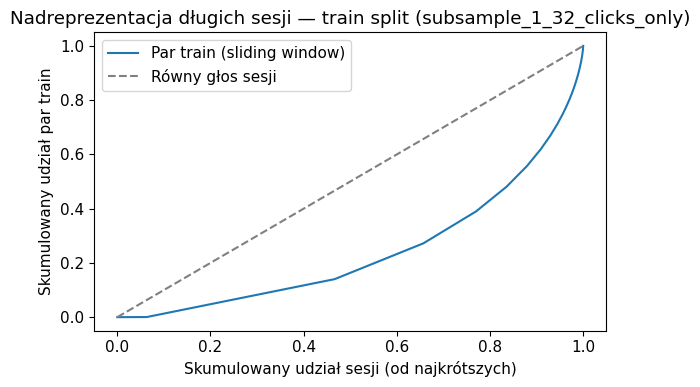

In [4]:
total_pairs = len(pairs)
total_sessions = len(session_lengths)

rows = []
for pct in [1, 5, 10, 20]:
    thr = session_lengths.quantile(1 - pct / 100)
    long_idx = session_lengths[session_lengths >= thr].index
    rows.append(
        {
            "Top % najdłuższych sesji": pct,
            "% sesji": len(long_idx) / total_sessions,
            "% par train": pairs_per_session.loc[long_idx].sum() / total_pairs,
        }
    )
display(pd.DataFrame(rows).set_index("Top % najdłuższych sesji"))

# do tekstu na slajd (sekcja 3)
SLIDE_TOP_SESS_PCT = 10
_thr = session_lengths.quantile(1 - SLIDE_TOP_SESS_PCT / 100)
_long_idx = session_lengths[session_lengths >= _thr].index
slide_top_pairs_share = 100 * pairs_per_session.loc[_long_idx].sum() / total_pairs

order = session_lengths.sort_values()
cum_sess = np.arange(1, len(order) + 1) / len(order)
cum_pairs = pairs_per_session.loc[order.index].cumsum() / total_pairs

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cum_sess, cum_pairs, label="Par train (sliding window)")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Równy głos sesji")
ax.set_xlabel("Skumulowany udział sesji (od najkrótszych)")
ax.set_ylabel("Skumulowany udział par train")
ax.set_title(f"Nadreprezentacja długich sesji — {label}")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Przykład z prezentacji — na prawdziwych itemach

Scenariusz z `first_presentation.md` w wersji Yoochoose:

- **`c1`** — item źródłowy (często klikany, użytkownik właśnie go oglądał).
- **`c2`** — najczęstszy **lokalny** następnik w parach train `c1 → ?` (często ten sam item — self-loop).
- **`c7`** — **globalnie** najpopularniejszy produkt w katalogu, ale rzadki jako następnik po `c1`.

Model widzi setki / tysiące razy `c1→c2`, a `c1→c7` (globalny lider) — dziesiątki razy.

In [5]:
def transition_stats(src: int) -> pd.DataFrame:
    """Dla itemu źródłowego: pary train vs sesje vs popularność globalna."""
    sub = pairs[pairs["item_id"] == src]
    pair_counts = sub["next_item"].value_counts()
    sess_counts = sub.groupby("next_item")["session_id"].nunique()
    rows = []
    for nxt in pair_counts.head(10).index:
        nxt = int(nxt)
        rows.append(
            {
                "next_item": nxt,
                "n_pairs_train": int(pair_counts[nxt]),
                "n_sessions": int(sess_counts[nxt]),
                "pairs_per_session": pair_counts[nxt] / sess_counts[nxt],
                "P_global_click": float(global_prob.get(nxt, 0)),
                "lift_vs_global": pair_counts[nxt] / len(sub)
                / float(global_prob.get(nxt, 1e-12)),
            }
        )
    return pd.DataFrame(rows)


def pick_slide_example(
    pairs_df: pd.DataFrame,
    global_top: int,
    *,
    top_sources: int = 30,
) -> tuple[int, int, int, int]:
    """Znajdź c1, gdzie lokalny lider c2 bije globalnego #1 w liczbie par train."""
    for src in pairs_df["item_id"].value_counts().head(top_sources).index.astype(int):
        sub = pairs_df[pairs_df["item_id"] == src]
        c2 = int(sub["next_item"].value_counts().index[0])
        n2 = int((sub["next_item"] == c2).sum())
        n7 = int((sub["next_item"] == global_top).sum())
        if n2 > n7 and c2 != global_top:
            return src, c2, n2, n7
    src = int(pairs_df["item_id"].value_counts().index[0])
    sub = pairs_df[pairs_df["item_id"] == src]
    c2 = int(sub["next_item"].value_counts().index[0])
    n2 = int((sub["next_item"] == c2).sum())
    n7 = int((sub["next_item"] == global_top).sum())
    return src, c2, n2, n7


global_top_item = int(global_pop.index[0])
print(
    f"Globalnie #1 item (najwięcej kliknięć): {global_top_item} "
    f"({int(global_pop.iloc[0]):,} kliknięć)"
)

top_sources = pairs["item_id"].value_counts().head(5).index.astype(int)
display(pd.Series(top_sources, name="top_source_item"))

Globalnie #1 item (najwięcej kliknięć): 214717003 (7,005 kliknięć)


0    214717003
1    214717007
2    214832557
3    214821022
4    214832559
Name: top_source_item, dtype: int64

In [6]:
c1, c2, n_pairs_c2, n_pairs_c7 = pick_slide_example(pairs, global_top_item)
c7 = global_top_item

n_sess_c2 = pairs.loc[(pairs["item_id"] == c1) & (pairs["next_item"] == c2), "session_id"].nunique()
n_sess_c7 = pairs.loc[(pairs["item_id"] == c1) & (pairs["next_item"] == c7), "session_id"].nunique()

slide = pd.DataFrame(
    {
        "Item": [f"c1 (źródło) = {c1}", f"c2 (top lokalny) = {c2}", f"c7 (global #1) = {c7}"],
        "Kliknięcia globalnie": [
            int(global_pop.get(c1, 0)),
            int(global_pop.get(c2, 0)),
            int(global_pop.get(c7, 0)),
        ],
        "Par train [c1]→?": ["—", n_pairs_c2, n_pairs_c7],
        "Sesji z przejściem c1→?": ["—", n_sess_c2, n_sess_c7],
        "Par / sesję": [
            "—",
            round(n_pairs_c2 / max(n_sess_c2, 1), 2),
            round(n_pairs_c7 / max(n_sess_c7, 1), 2),
        ],
    }
)
display(slide)

print(f"\nInterpretacja ({label}):")
print(f"  Po kliknięciu c1={c1} model na trainie widzi c1→c2 {n_pairs_c2}× vs c1→c7 {n_pairs_c7}×.")
print(f"  Tymczasem c7 jest #1 w całym katalogu ({int(global_pop[c7]):,} kliknięć), a c2 nie.")
if c1 == c2:
    print("  c2 = c1 → klasyczny self-loop (jak w tabeli lift z EDA).")

,Item,Kliknięcia globalnie,Par train [c1]→?,Sesji z przejściem c1→?,Par / sesję
0,c1 (źródło) = 214717007,6344,—,—,—
1,c2 (top lokalny) = 214717007,6344,1318,860,1.53
2,c7 (global #1) = 214717003,7005,647,619,1.05



Interpretacja (train split (subsample_1_32_clicks_only)):
  Po kliknięciu c1=214717007 model na trainie widzi c1→c2 1318× vs c1→c7 647×.
  Tymczasem c7 jest #1 w całym katalogu (7,005 kliknięć), a c2 nie.
  c2 = c1 → klasyczny self-loop (jak w tabeli lift z EDA).


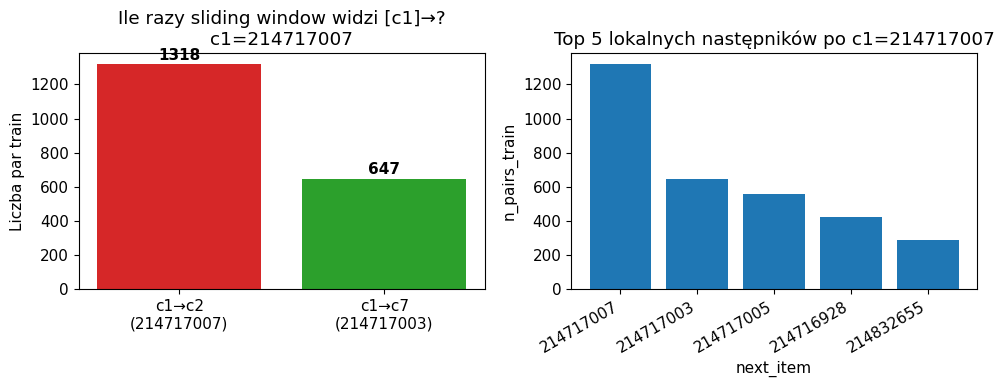

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
bar_labels = [f"c1→c2\n({c2})", f"c1→c7\n({c7})"]
bar_vals = [n_pairs_c2, n_pairs_c7]
ax.bar(bar_labels, bar_vals, color=["#d62728", "#2ca02c"])
ax.set_title(f"Ile razy sliding window widzi [c1]→?\nc1={c1}")
ax.set_ylabel("Liczba par train")
for i, v in enumerate(bar_vals):
    ax.text(i, v + max(bar_vals) * 0.02, str(v), ha="center", fontweight="bold")

ax = axes[1]
top = transition_stats(c1).head(5)
x = top["next_item"].astype(str)
ax.bar(x, top["n_pairs_train"], color="#1f77b4")
ax.set_title(f"Top 5 lokalnych następników po c1={c1}")
ax.set_xlabel("next_item")
ax.set_ylabel("n_pairs_train")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

Użyj tabeli `slide` i wykresów powyżej. Szablon:

> **Yoochoose ({label}):** po kliknięciu produktu **c1** model na trainie (sliding window) widzi przejście **c1→c2** ok. **{n_pairs_c2}** razy, a do globalnie najpopularniejszego **c7** tylko **{n_pairs_c7}** razy — mimo że **c7** ma najwięcej kliknięć w całym sklepie.

Dodatkowo **{pct}%** najdłuższych sesji generuje **~{share}%** wszystkich par train — długie ścieżki przeglądania ważą loss bardziej niż krótkie sesje.

## 4. Tabela lift (jak w EDA) — top źródła

Ta sama logika co komórka „Kaskadowość” w [`eda_yoochose.ipynb`](eda_yoochose.ipynb): self-loopy mają ogromny lift względem globalnej popularności.

In [8]:
bias_rows = []
for src in pairs["item_id"].value_counts().head(5).index.astype(int):
    sub = pairs[pairs["item_id"] == src]
    cond = sub["next_item"].value_counts(normalize=True)
    top_next = int(cond.index[0])
    g = float(global_prob.get(top_next, 0))
    bias_rows.append(
        {
            "source_item": src,
            "top_next": top_next,
            "P(next|source)": cond.iloc[0],
            "P(next) globalnie": g,
            "lift": cond.iloc[0] / g if g > 0 else np.inf,
            "n_pairs": int((sub["next_item"] == top_next).sum()),
            "n_sessions": int(sub.loc[sub["next_item"] == top_next, "session_id"].nunique()),
        }
    )

bias_df = pd.DataFrame(bias_rows)
display(bias_df)

,source_item,top_next,P(next|source),P(next) globalnie,lift,n_pairs,n_sessions
0,214717003,214717003,0.322587,0.008782,36.734481,1761,1136
1,214717007,214717007,0.258990,0.007953,32.565336,1318,860
2,214832557,214832557,0.221442,0.008189,27.042654,1072,786
3,214821022,214718169,0.223245,0.003602,61.984358,970,924
4,214832559,214832559,0.199953,0.007028,28.451858,851,640


## 5. Automatyczne wyszukanie przykładów „c1→c2 dominuje nad c1→global_top”

Przeszukuje top źródła i pokazuje przypadki, gdzie lokalny lider (często self-loop) bije globalnie #1 produkt **w liczbie par train**.

In [9]:
examples = []
for src in pairs["item_id"].value_counts().head(30).index.astype(int):
    sub = pairs[pairs["item_id"] == src]
    c2 = int(sub["next_item"].value_counts().index[0])
    n2 = int((sub["next_item"] == c2).sum())
    n7 = int((sub["next_item"] == global_top_item).sum())
    if n2 > n7 and c2 != global_top_item:
        examples.append(
            {
                "c1": src,
                "c2_local_top": c2,
                "n_pairs_c1_c2": n2,
                "c7_global_top": global_top_item,
                "n_pairs_c1_c7": n7,
                "ratio_c2_over_c7": round(n2 / max(n7, 1), 1),
            }
        )

examples_df = pd.DataFrame(examples).sort_values("ratio_c2_over_c7", ascending=False)
display(examples_df.head(10))

,c1,c2_local_top,n_pairs_c1_c2,c7_global_top,n_pairs_c1_c7,ratio_c2_over_c7
1,214832557,214832557,1072,214717003,1,1072.0
2,214821022,214718169,970,214717003,1,970.0
7,214821020,214821020,907,214717003,1,907.0
16,214748336,214748336,874,214717003,0,874.0
3,214832559,214832559,851,214717003,1,851.0
4,214718160,214821024,796,214717003,1,796.0
26,214718169,214821022,629,214717003,0,629.0
22,214829282,214829282,604,214717003,1,604.0
21,214718220,214718220,559,214717003,1,559.0
6,214821024,214718160,888,214717003,2,444.0


---

**Podsumowanie:** kaskadowość na Yoochoose to nie abstrakcja — widać ją w:
1. **Self-loopach** (`source_item == top_next`, wysoki `lift`).
2. **Rozjeździe par train vs globalna popularność** (sekcja 3).
3. **Wadze długich sesji** w lossie (sekcja 2).

Decyzje preprocessingu: [`docs/data-and-eda.md`](../docs/data-and-eda.md) §4.